link doesnt work so bert was downloaded locally and not uploaded to github


In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text

/Users/tajbirhasanshuvo/micromamba/envs/tf-m1/lib/python3.10/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [3]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1','v2']]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.groupby('v1').describe()

v2                                                               
     count unique                                                top freq
v1                                                                       
ham   4825   4516                             Sorry, I'll call later   30
spam   747    653  Please call our customer service representativ...    4

In [5]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
df_spam = df[df['v1']=='spam']
df_spam.shape

(747, 2)

In [7]:
df_ham = df[df['v1']=='ham']
df_ham.shape

(4825, 2)

In [8]:
df_ham = df_ham.sample(df_spam.shape[0])
df_ham.shape

(747, 2)

In [9]:
df_new = pd.concat([df_ham,df_spam])
df_new.shape

(1494, 2)

In [10]:
df_new['spam'] = df_new['v1'].apply(lambda x: 1 if x=='spam' else 0)
df_new.sample(5)

,v1,v2,spam
2704,spam,FreeMsg: Fancy a flirt? Reply DATE now & join ...,1
822,spam,"SMSSERVICES. for yourinclusive text credits, p...",1
959,ham,Where @,0
2087,ham,\alright babe,0
1077,ham,"Yep, by the pretty sculpture",0


In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test , y_train, y_test = train_test_split(df_new['v2'],df_new['spam'],stratify=df_new['spam'])

In [12]:
x_train.head()

2523                               Sorry, I'll call later
3121    Free entry in 2 a weekly comp for a chance to ...
3828             Sure, I'll see if I can come by in a bit
2845                     Wat time u finish ur lect today?
1963    Yes :)it completely in out of form:)clark also...
Name: v2, dtype: object

In [13]:
preprocessor_path = "./bert_preprocess"
encoder_path = "./bert_encoder"

In [14]:
preprocessor = hub.KerasLayer(preprocessor_path)
encoder = hub.KerasLayer(encoder_path)

2025-10-20 23:35:03.727537: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-10-20 23:35:03.727562: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-20 23:35:03.727570: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1760981703.727584 46122766 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1760981703.727601 46122766 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-10-20 23:35:04.494603: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [15]:
def get_sent_embedding(sent):
    
    preprocessed_text= preprocessor(sent)
    return encoder(preprocessed_text)['pooled_output']
    

In [16]:
e = get_sent_embedding([
    "banana",
    "grapes",
    "mango",
    "elon musk",
    "bill gates",
    "jegg bezos"
])

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

In [18]:
e

<tf.Tensor: shape=(6, 768), dtype=float32, numpy=
array([[-0.8349478 ,  0.6283764 ,  0.9999889 , ...,  0.9999963 ,
         0.47890186,  0.98894864],
       [-0.646563  ,  0.2901055 ,  0.9996065 , ...,  0.9998905 ,
        -0.74512553,  0.9699663 ],
       [-0.377309  ,  0.23452324,  0.9986029 , ...,  0.99963367,
        -0.8270202 ,  0.8739304 ],
       [-0.7615177 ,  0.46662885,  0.9999175 , ...,  0.9999793 ,
        -0.39281896,  0.9895317 ],
       [-0.73615664,  0.46377066,  0.99996275, ...,  0.9999893 ,
        -0.13783188,  0.99382293],
       [-0.7018685 ,  0.5192562 ,  0.9998328 , ...,  0.9999278 ,
        -0.54255563,  0.9677634 ]], dtype=float32)>

In [19]:
cosine_similarity([e[3]],[e[4]])

array([[0.9464902]], dtype=float32)

In [20]:
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
output = encoder(preprocessor(text_input))  # dict output

x = tf.keras.layers.Dropout(0.1, name='dropout')(output['pooled_output'])
x = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(x)

model = tf.keras.Model(inputs=text_input, outputs=x)

In [21]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 keras_layer (KerasLayer)    {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                              

In [22]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [24]:

model.fit(x_train, y_train, epochs=10)

Epoch 1/10
35/35 [==============================] - 96s 3s/step - loss: 0.6934 - accuracy: 0.5482 - precision: 0.5486 - recall: 0.5446
Epoch 2/10
35/35 [==============================] - 100s 3s/step - loss: 0.6392 - accuracy: 0.6277 - precision: 0.6293 - recall: 0.6214
Epoch 3/10
35/35 [==============================] - 102s 3s/step - loss: 0.6153 - accuracy: 0.6652 - precision: 0.6494 - recall: 0.7179
Epoch 4/10
35/35 [==============================] - 94s 3s/step - loss: 0.6088 - accuracy: 0.6786 - precision: 0.6695 - recall: 0.7054
Epoch 5/10
35/35 [==============================] - 92s 3s/step - loss: 0.5992 - accuracy: 0.6902 - precision: 0.6846 - recall: 0.7054
Epoch 6/10
35/35 [==============================] - 93s 3s/step - loss: 0.5694 - accuracy: 0.7134 - precision: 0.7043 - recall: 0.7357
Epoch 7/10
35/35 [==============================] - 92s 3s/step - loss: 0.5560 - accuracy: 0.7286 - precision: 0.7148 - recall: 0.7607
Epoch 8/10
35/35 [==============================] - 1

In [25]:

model.evaluate(x_test, y_test)

12/12 [==============================] - 33s 3s/step - loss: 0.4916 - accuracy: 0.7861 - precision: 0.7635 - recall: 0.8289


[0.4916444718837738,
 0.7860962748527527,
 0.7635468244552612,
 0.8288770318031311]

In [26]:
y_predicted = model.predict(x_test)
y_predicted = y_predicted.flatten()

12/12 [==============================] - 34s 3s/step


In [27]:
import numpy as np

y_predicted = np.where(y_predicted > 0.5, 1, 0)
y_predicted

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,

In [28]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predicted)
cm 


array([[139,  48],
       [ 32, 155]])

Text(50.722222222222214, 0.5, 'Truth')

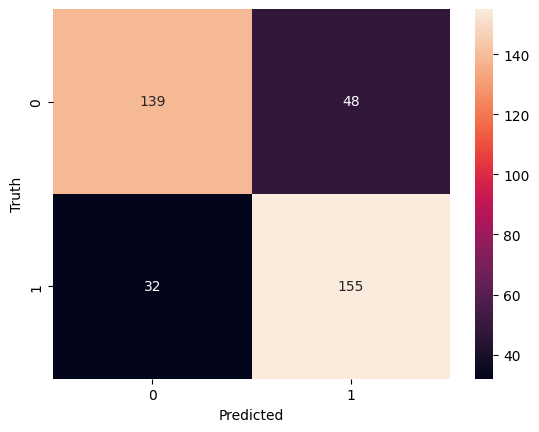

In [29]:
from matplotlib import pyplot as plt
import seaborn as sn
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [30]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.81      0.74      0.78       187
           1       0.76      0.83      0.79       187

    accuracy                           0.79       374
   macro avg       0.79      0.79      0.79       374
weighted avg       0.79      0.79      0.79       374



In [31]:

reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]
model.predict(reviews)

1/1 [==============================] - 3s 3s/step


array([[0.40809694],
       [0.7739547 ],
       [0.5420284 ],
       [0.23449439],
       [0.4126808 ]], dtype=float32)